In [155]:
import numpy as np
import pandas as pd
from scipy.interpolate import LinearNDInterpolator
import ternary
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.tri as tri

In [156]:
MARG = pd.read_excel(r"All Ternary.xlsx", sheet_name = 'MARG')
VAN = pd.read_excel(r"All Ternary.xlsx", sheet_name = 'VAN')
WILSON = pd.read_excel(r"All Ternary.xlsx", sheet_name = 'WILSON')

In [157]:
datasets = [
        (WILSON, 'Ternary Diagram - Wilson Method'),
        (VAN, 'Ternary Diagram - Van Laar Method'),
        (MARG, 'Ternary Diagram - Margules Method')
    ]

In [163]:
def plot_ternary(df, ax, title, scale=100):
    df_copy = df.copy()
    
    # Normalize fractions
    total = df_copy[['x1', 'x2', 'x3']].sum(axis=1)
    df_copy[['x1', 'x2', 'x3']] = df_copy[['x1', 'x2', 'x3']].div(total, axis=0)
    
    # Interpolation
    points = df_copy[['x1', 'x2']].values
    values = df_copy['P (bar)'].values
    interp = LinearNDInterpolator(points, values)
   
    # Grid
    heatmap_data = {}
    for i in range(scale + 1):
        for j in range(scale + 1 - i):
            k = scale - i - j
            x1, x2 = i / scale, j / scale
            p_val = interp([[x1, x2]])[0]
            if np.isfinite(p_val):
                heatmap_data[(i, j, k)] = float(p_val)
    vmin = min(heatmap_data.values())
    vmax = max(heatmap_data.values())
   
    # Ternary subplots
    tax = ternary.TernaryAxesSubplot(ax=ax, scale=scale)
    ax.axis("off")
   
    # Heatmap
    tax.heatmap(
        heatmap_data,
        style="triangular",
        cmap='jet',
        vmin=vmin,
        vmax=vmax,
        colorbar=False
    )
    
    # Resyncing the color bar just to add a label
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm = cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Pressure (bar)", size = 14)
           
    # Project points to 2D cartesian
    coords = df_copy[['x1', 'x2', 'x3']].values * scale
    cartesian_points = [ternary.helpers.project_point(row) for row in coords]
    x_cart = np.array([p[0] for p in cartesian_points])
    y_cart = np.array([p[1] for p in cartesian_points])

    # Custom legend
    legend_elements = [
        Line2D([0], [0], color='red', lw=2, label='K1 = 1'),
        Line2D([0], [0], color='blue', lw=2, linestyle='--', label='K2 = 1'),
        Line2D([0], [0], color='green', lw=2, linestyle=':', label='K3 = 1')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    # Styling
    tax.boundary(linewidth=1.2)
    tax.gridlines(multiple=10, color="gray", linewidth=0.4, alpha=0.5)
    tax.ticks(axis='lbr', multiple=10, linewidth=0.8, tick_formats="%.0f", offset=0.02)

    # Labels
    tax.set_title(title, pad=20, size = 18)
    tax.left_axis_label("Ethyl Acetate (mol %)", offset=0.14, size = 16)
    tax.right_axis_label("Methyl Acetate (mol %)", offset=0.14, size = 16)
    tax.bottom_axis_label("Ethanol (mol %)", offset=0.08, size = 16)
    
    # Prevent double ticks
    tax.clear_matplotlib_ticks()
    tax._redraw_labels()

In [159]:
def generate_ternary_grid(step=0.01):

    pts = []

    values = np.arange(0, 1 + step, step)

    for x1 in values:
        for x2 in values:

            x3 = 1.0 - x1 - x2

            # Keep only valid simplex points
            if x3 < -1e-12:
                continue

            # Numerical cleanup
            x3 = round(x3, 10)

            pts.append((x1, x2, x3))

    df = pd.DataFrame(
        pts,
        columns=['x1', 'x2', 'x3']
    )

    return df

In [160]:
def ternary_to_cartesian(x1, x2, x3):
    """
    x1 = Ethanol
    x2 = Ethyl Acetate
    x3 = Methyl Acetate
    """

    X = x3 + 0.5 * x1
    Y = (np.sqrt(3) / 2.0) * x1

    return X, Y


def cartesian_to_ternary(X, Y):
    """
    Inverse transform
    """

    x1 = Y / (np.sqrt(3) / 2.0)
    x3 = X - 0.5 * x1
    x2 = 1.0 - x1 - x3

    return x1, x2, x3

In [177]:
def plot_k_contours(df, ax, title, scale=100):

    df = df.copy()

    for k in ['K1', 'K2', 'K3']:
        df[k] = pd.to_numeric(df[k], errors='coerce')

    df = df.replace([np.inf, -np.inf], np.nan)

    df = df.dropna(
        subset=['x1','x2','x3','K1','K2','K3']
    )

    # Normalize compositions
    total = df[['x1','x2','x3']].sum(axis=1)

    df[['x1','x2','x3']] = (
        df[['x1','x2','x3']]
        .div(total, axis=0)
    )

    # Cartesian coordinates
    X, Y = ternary_to_cartesian(
        df['x1'].values,
        df['x2'].values,
        df['x3'].values
    )

    # Triangulation
    triang = tri.Triangulation(X, Y)

    # Create ternary axes
    tax = ternary.TernaryAxesSubplot(
        ax=ax,
        scale=scale
    )

    ax.axis("off")

    tax.boundary(linewidth=1.5)

    tax.gridlines(
        multiple=10,
        color="gray",
        linewidth=0.5,
        alpha=0.5
    )

    tax.ticks(
        axis='lbr',
        multiple=10,
        linewidth=1,
        tick_formats="%.0f",
        offset=0.02
    )

    tax.set_title(title, fontsize=18)

    tax.left_axis_label(
        "Ethyl Acetate (mol %)",
        offset=0.14,
        fontsize=14
    )

    tax.right_axis_label(
        "Methyl Acetate (mol %)",
        offset=0.14,
        fontsize=14
    )

    tax.bottom_axis_label(
        "Ethanol (mol %)",
        offset=0.08,
        fontsize=14
    )

    tax.clear_matplotlib_ticks()
    tax._redraw_labels()

    # Contour definitions
    k_configs = [
        ('K1', 'blue',  'EtOH K=1'),
        ('K2', 'red',   'EtOAc K=1'),
        ('K3', 'green', 'MeOAc K=1'),
    ]

    # Extract contours
    for k_col, color, label in k_configs:
    
        Z = df[k_col].values - 1.0
    
        contour = ax.tricontour(
            triang,
            Z,
            levels=[-0.0005, 0.0005]
        )
    
        for seg in contour.allsegs[0]:
    
            if len(seg) < 2:
                continue
    
            x_cart = seg[:, 0]
            y_cart = seg[:, 1]
    
            x1, x2, x3 = cartesian_to_ternary(
                x_cart,
                y_cart
            )
    
            ternary_points = list(zip(
                x2 * scale,
                x3 * scale,
                x1 * scale
            ))
    
            tax.plot(
                ternary_points,
                color=color,
                linewidth=2
            )
    
        # remove temporary contour artists
        contour.remove()
    
    # Legend
    legend_elements = [
        Line2D(
            [0],[0],
            color='blue',
            lw=2,
            label='EtOH K=1'
        ),

        Line2D(
            [0],[0],
            color='red',
            lw=2,
            label='EtOAc K=1'
        ),

        Line2D(
            [0],[0],
            color='green',
            lw=2,
            label='MeOAc K=1'
        ),
    ]

    ax.legend(
        handles=legend_elements,
        loc='upper left',
        fontsize=12
    )

    return tax

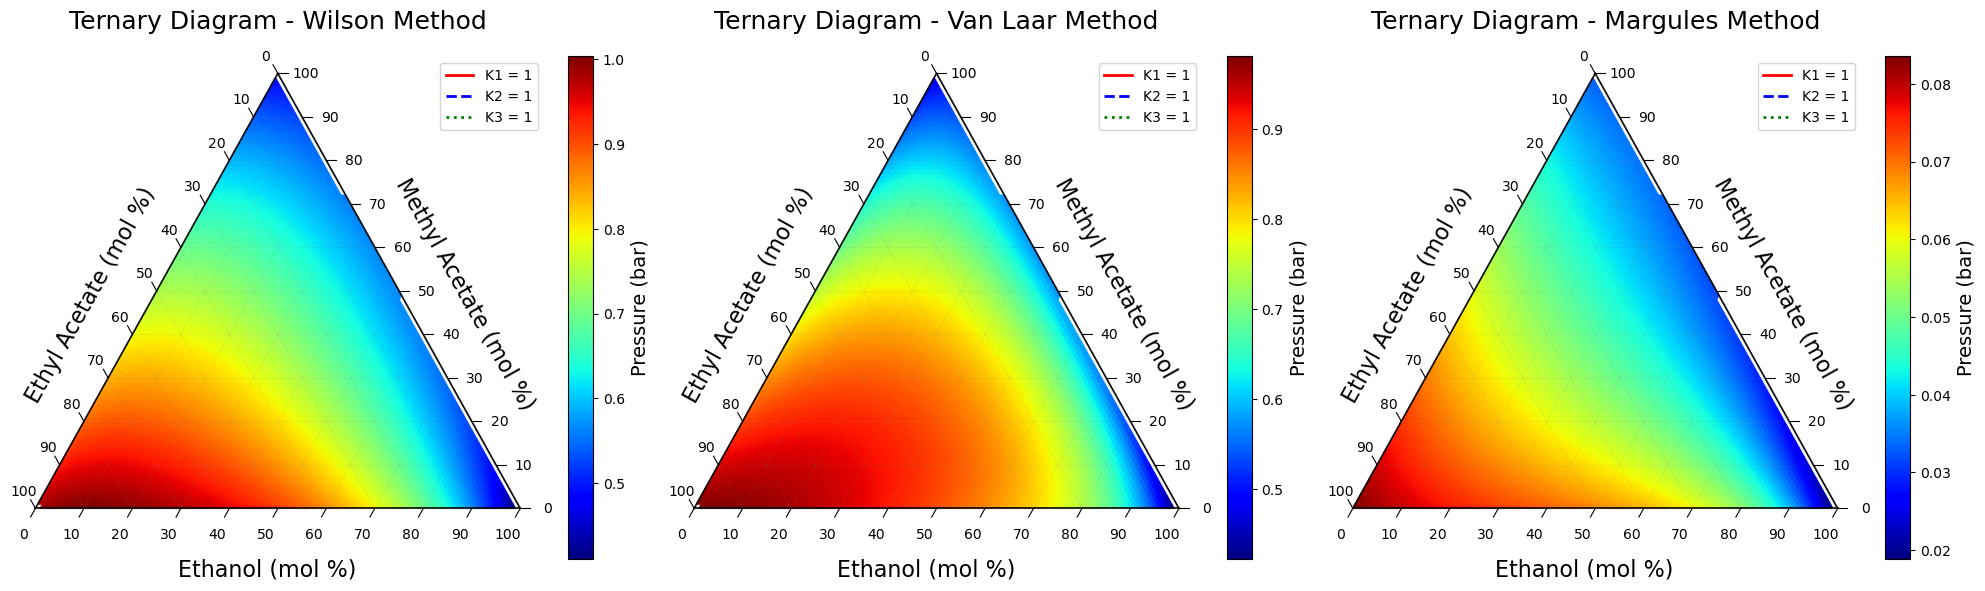

In [167]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for (data, title), ax in zip(datasets, axes):
    plot_ternary(data, ax, title)

plt.tight_layout()
plt.savefig("ternary.pdf")
plt.show()

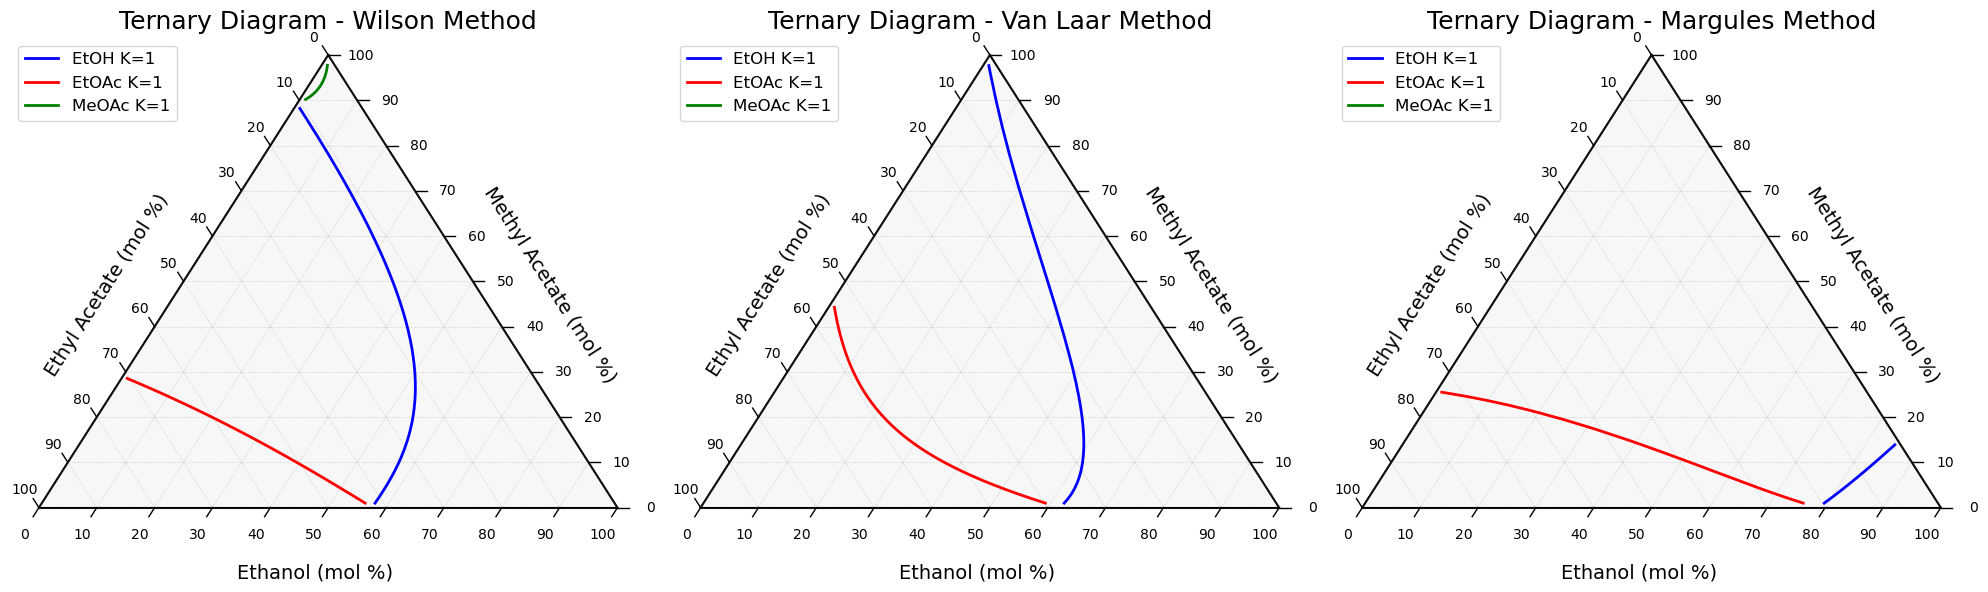

In [176]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for (data, title), ax in zip(datasets, axes):
    plot_k_contours(data, ax, title)
    
plt.tight_layout()
plt.savefig("ternary_k.pdf")
plt.show()